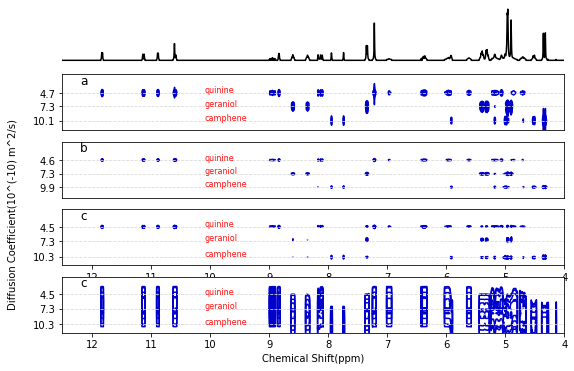

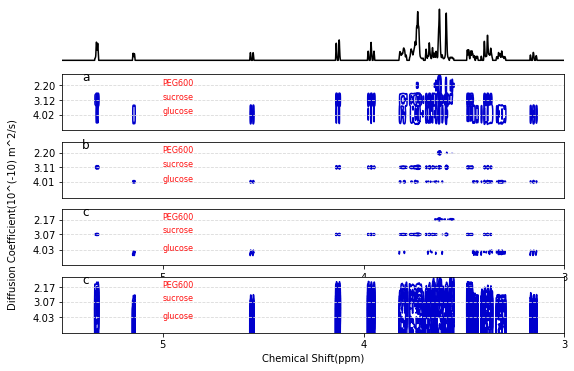

In [9]:
import config
import numpy as np
import scipy.io as scio
import torch
import matplotlib.pyplot as plt
from model import Transformer
from scipy import interpolate


def contourDOSY(Type, Result_LRsPILT, Result_CoMeF, Z, HNMR, b, ppm, cs, idx_peaks, cs1, cs2, dc1, dc2, fig, axs, var):
    # implementation of the function
    cs_spec = np.zeros([(ppm.size), 1])
    spec_whole = np.zeros([len(Z[0, :]), ppm.size])
    spec_var = np.zeros([len(Z[0, :]), ppm.size])
    cs_spec[idx_peaks, :] = HNMR
    spec_whole[0:140, idx_peaks[0, :]] = Z.T
    decay_range = np.linspace(0, (len(Z[0, :]) - 1) / 10, len(Z[0, :]))
    spec_var[0:140, idx_peaks[0, :]] = var.T

    axs[0].plot(ppm.reshape(ppm.size), cs_spec, color='k')
    axs[0].set_xlim([cs1, cs2])
    axs[0].invert_xaxis()
    axs[0].axis('off')
    if Type == "QGC":
        # 绘制第二个图
        DiffCoef = [4.7, 7.3, 10.1]
        # axs[1] = plt.subplot(3, 1, 1)
        im = axs[1].contour(ppm.reshape(ppm.size), np.linspace(1, 20, 191), Result_LRsPILT,
                            [0.025, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')
        #         im = ax2.contourf(ppm['ppm'].reshape(ppm['ppm'].size), np.linspace(1, 20, 191), Result_LRsPILT, 40)
        axs[1].set_xlim([cs1, cs2])
        axs[1].set_ylim([dc1, dc2])
        axs[1].text(12.2, 3, 'a', fontsize=12)
        axs[1].text(10.1, 4.66, "quinine", fontsize=8, color=[1, 0.07, 0.07])
        axs[1].text(10.1, 7.26, "geraniol", fontsize=8, color=[1, 0.07, 0.07])
        axs[1].text(10.1, 10.06, "camphene", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[1].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[1].set_yticks(np.unique(DiffCoef))
            axs[1].set_xticks([])
            axs[1].invert_yaxis()
            axs[1].invert_xaxis()

        # CoMeF
        # axs[2] = plt.subplot(3, 1, 2)
        DiffCoef = [4.6, 7.3, 9.9]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), np.linspace(1, 12, 100))
        axs[2].contour(CS, DC, Result_CoMeF, [0.02, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[2].set_xlim([cs1, cs2])
        axs[2].set_ylim([dc1, dc2])
        axs[2].text(12.2, 3, 'b', fontsize=12)
        axs[2].text(10.1, 4.66, "quinine", fontsize=8, color=[1, 0.07, 0.07])
        axs[2].text(10.1, 7.26, "geraniol", fontsize=8, color=[1, 0.07, 0.07])
        axs[2].text(10.1, 9.86, "camphene", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[2].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[2].set_yticks(np.unique(DiffCoef))
            axs[2].set_xticks([])
            axs[2].invert_yaxis()
            axs[2].invert_xaxis()
        #         # DRILT
        # axs[3] = plt.subplot(3, 1, 3)
        DiffCoef = [4.5, 7.3, 10.3]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), decay_range * (0.8 / b[0, -1]))

        axs[3].contour(CS, DC, spec_whole, [0.014, 0.02, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[3].set_xlim([cs1, cs2])
        axs[3].set_ylim([dc1, dc2])
        axs[3].text(12.2, 3, 'c', fontsize=12)
        axs[3].text(10.1, 4.46, "quinine", fontsize=8, color=[1, 0.07, 0.07])
        axs[3].text(10.1, 7.16, "geraniol", fontsize=8, color=[1, 0.07, 0.07])
        axs[3].text(10.1, 10.36, "camphene", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[3].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[3].set_yticks(np.unique(DiffCoef))
            axs[3].set_xticks(np.arange(cs1, cs2))
            axs[3].invert_yaxis()
            axs[3].invert_xaxis()
        
        DiffCoef = [4.5, 7.3, 10.3]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), decay_range * (0.8 / b[0, -1]))

        axs[4].contour(CS, DC, spec_var, [0.014, 0.02, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[4].set_xlim([cs1, cs2])
        axs[4].set_ylim([dc1, dc2])
        axs[4].text(12.2, 3, 'c', fontsize=12)
        axs[4].text(10.1, 4.46, "quinine", fontsize=8, color=[1, 0.07, 0.07])
        axs[4].text(10.1, 7.16, "geraniol", fontsize=8, color=[1, 0.07, 0.07])
        axs[4].text(10.1, 10.36, "camphene", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[4].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[4].set_yticks(np.unique(DiffCoef))
            axs[4].set_xticks(np.arange(cs1, cs2))
            axs[4].invert_yaxis()
            axs[4].invert_xaxis()
              
    elif Type == "GSP":

        DiffCoef = [2.2, 3.12, 4.02]

        im = axs[1].contour(ppm.reshape(ppm.size), np.linspace(0, 7, 351), Result_LRsPILT, [0.02, 0.1, 0.2, 0.7, 1],
                            colors='mediumblue')
        # im = ax2.contourf(ppm['ppm'].reshape(ppm['ppm'].size), np.linspace(1, 20, 191), Result_LRsPILT, 40)
        axs[1].set_xlim([cs1, cs2])
        axs[1].set_ylim([dc1, dc2])
        axs[1].text(5.4, 1.9, 'a', fontsize=12)
        axs[1].text(5.0, 2.2, "PEG600", fontsize=8, color=[1, 0.07, 0.07])
        axs[1].text(5.0, 3.07, "sucrose", fontsize=8, color=[1, 0.07, 0.07])
        axs[1].text(5.0, 3.97, "glucose", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[1].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[1].set_yticks(np.unique(DiffCoef))
            axs[1].set_xticks([])
            axs[1].invert_yaxis()
            axs[1].invert_xaxis()

        # CoMeF
        DiffCoef = [2.2, 3.11, 4.01]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), np.linspace(1.5, 5, 100))
        axs[2].contour(CS, DC, Result_CoMeF, [0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[2].set_xlim([cs1, cs2])
        axs[2].set_ylim([dc1, dc2])
        axs[2].text(5.4, 1.9, 'b', fontsize=12)
        axs[2].text(5.0, 2.2, "PEG600", fontsize=8, color=[1, 0.07, 0.07])
        axs[2].text(5.0, 3.07, "sucrose", fontsize=8, color=[1, 0.07, 0.07])
        axs[2].text(5.0, 3.97, "glucose", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[2].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[2].set_yticks(np.unique(DiffCoef))
            axs[2].set_xticks([])
            axs[2].invert_yaxis()
            axs[2].invert_xaxis()
        #         # DRILT

        DiffCoef = [2.17, 3.07, 4.03]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), decay_range * (0.8 / b[0, -1]))

        axs[3].contour(CS, DC, spec_whole, [0.01, 0.03, 0.04, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[3].set_xlim([cs1, cs2])
        axs[3].set_ylim([dc1, dc2])
        axs[3].text(5.4, 1.9, 'c', fontsize=12)
        axs[3].text(5.0, 2.16, "PEG600", fontsize=8, color=[1, 0.07, 0.07])
        axs[3].text(5.0, 2.97, "sucrose", fontsize=8, color=[1, 0.07, 0.07])
        axs[3].text(5.0, 4.09, "glucose", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[3].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[3].set_yticks(np.unique(DiffCoef))
            axs[3].set_xticks(np.arange(cs1, cs2))
            axs[3].invert_yaxis()
            axs[3].invert_xaxis()

        DiffCoef = [2.17, 3.07, 4.03]
        CS, DC = np.meshgrid(ppm.reshape(ppm.size), decay_range * (0.8 / b[0, -1]))

        axs[4].contour(CS, DC, spec_var, [0.01, 0.03, 0.04, 0.05, 0.1, 0.2, 0.7, 1], colors='mediumblue')

        axs[4].set_xlim([cs1, cs2])
        axs[4].set_ylim([dc1, dc2])
        axs[4].text(5.4, 1.9, 'c', fontsize=12)
        axs[4].text(5.0, 2.16, "PEG600", fontsize=8, color=[1, 0.07, 0.07])
        axs[4].text(5.0, 2.97, "sucrose", fontsize=8, color=[1, 0.07, 0.07])
        axs[4].text(5.0, 4.09, "glucose", fontsize=8, color=[1, 0.07, 0.07])

        for i in range(len(DiffCoef)):
            axs[4].axhline(y=DiffCoef[i], linestyle='--', linewidth=0.8, color=[0.85, 0.85, 0.85])
            axs[4].set_yticks(np.unique(DiffCoef))
            axs[4].set_xticks(np.arange(cs1, cs2))
            axs[4].invert_yaxis()
            axs[4].invert_xaxis()
    plt.xlabel('Chemical Shift(ppm)')
    fig.text(0.04, 0.4, 'Diffusion Coefficient(10^(-10) m^2/s)', va='center', rotation='vertical')

    pass


if __name__ == '__main__':

    Type = "QGC"
    NmrData = scio.loadmat("./Dataset/" + Type + "_net_input.mat")
    with torch.no_grad():
        module = Transformer.load_from_checkpoint("Result/DOSY/last.ckpt")
        module.prepare_for_testing()

    NmrDatai = np.zeros([NmrData['S'].shape[0], 30])
    for i in np.arange(NmrData['S'].shape[0]):
        f = interpolate.interp1d(NmrData['b'][0], NmrData['S'][i, :], fill_value='extrapolate')
        NmrDatai[i] = f(np.linspace(0, np.max(NmrData['b'][0]), 30))
    test_input = NmrDatai[np.newaxis, :, :]

    test_input = torch.tensor(test_input)
    test_input = test_input.to(torch.float32)
    test_out,var = module(test_input)

    test_out = test_out * test_input[:, :, 0][:, :, np.newaxis]
    test_out = test_out[0].cpu().detach().numpy()
    test_out[test_out < np.tile(((np.max(test_out, axis=1)) * 0.7)[:, np.newaxis], [1, 140])] = 0

    var = var[0].cpu().detach().numpy()

    scio.savemat("./MATLAB/Result/" + Type + "_Result.mat", {"Z": test_out})

    # load data
    QGC_b = scio.loadmat('MATLAB/Data/QGC/QGC_b.mat')['b']
    QGC_idx_peaks = scio.loadmat('MATLAB/Data/QGC/QGC_idx_peaks.mat')['idx_peaks']
    QGC_ppm = scio.loadmat('MATLAB/Data/QGC/QGC_ppm.mat')['ppm']
    QGC_HNMR = scio.loadmat('MATLAB/Data/QGC/QGC_HNMR.mat')['HNMR']
    QGC_Result = scio.loadmat('MATLAB/Result/QGC_Result.mat')['Z']
    QGC_Result_LRsPILT = scio.loadmat('MATLAB/Result/QGC_Result_LRsPILT.mat')['QGC_Result_LRsPILT']
    QGC_Result_CoMeF = scio.loadmat('MATLAB/Result/QGC_Result_CoMeF.mat')['QGC_Result_CoMeF']

    # plot figure
    Type = "QGC"
    cs1 = 4
    cs2 = 12.5
    dc1 = 1
    dc2 = 12
    cs = []
    fig, axs = plt.subplots(5, 1, figsize=(9, 6))
    contourDOSY(Type, QGC_Result_LRsPILT, QGC_Result_CoMeF, QGC_Result, QGC_HNMR, QGC_b, QGC_ppm, cs, QGC_idx_peaks,
                cs1, cs2, dc1, dc2, fig, axs, var)

    Type = "GSP"
    NmrData = scio.loadmat("./Dataset/" + Type + "_net_input.mat")

    NmrDatai = np.zeros([NmrData['S'].shape[0], 30])
    for i in np.arange(NmrData['S'].shape[0]):
        f = interpolate.interp1d(NmrData['b'][0], NmrData['S'][i, :], fill_value='extrapolate')
        NmrDatai[i] = f(np.linspace(0, np.max(NmrData['b'][0]), 30))
    test_input = NmrDatai[np.newaxis, :, :]

    test_input = torch.tensor(test_input)
    test_input = test_input.to(torch.float32)
    test_out,var = module(test_input)

    test_out = test_out * test_input[:, :, 0][:, :, np.newaxis]
    test_out = test_out[0].cpu().detach().numpy()
    test_out[test_out < np.tile(((np.max(test_out, axis=1)) * 0.7)[:, np.newaxis], [1, 140])] = 0

    var = var[0].cpu().detach().numpy()

    scio.savemat("./MATLAB/Result/" + Type + "_Result.mat", {"Z": test_out})

    GSP_b = scio.loadmat('MATLAB/Data/GSP/GSP_b.mat')['b']
    GSP_idx_peaks = scio.loadmat('MATLAB/Data/GSP/GSP_idx_peaks.mat')['idx_peaks']
    GSP_ppm = scio.loadmat('MATLAB/Data/GSP/GSP_ppm.mat')['ppm']
    GSP_HNMR = scio.loadmat('MATLAB/Data/GSP/GSP_HNMR.mat')['HNMR']
    GSP_Result = scio.loadmat('MATLAB/Result/GSP_Result.mat')['Z']
    GSP_Result_LRsPILT = scio.loadmat('MATLAB/Result/GSP_Result_LRsPILT.mat')['GSP_Result_LRsPILT']
    GSP_Result_CoMeF = scio.loadmat('MATLAB/Result/GSP_Result_CoMeF.mat')['GSP_Result_CoMeF']

    cs1 = 3
    cs2 = 5.5
    dc1 = 1.5
    dc2 = 5
    cs = []
    fig2, axs2 = plt.subplots(5, 1, figsize=(9, 6))
    contourDOSY(Type, GSP_Result_LRsPILT, GSP_Result_CoMeF, GSP_Result, GSP_HNMR, GSP_b, GSP_ppm, cs, GSP_idx_peaks,
                cs1, cs2, dc1, dc2, fig2, axs2, var)

    plt.show()